# Peramalan Moving Average Properti Menggunakan Random Forest

Notebook ini memakai dataset `ma_lga_12345.csv` untuk meramalkan nilai `MA` properti per kombinasi `type` dan `bedrooms`. Data bersifat kuartalan, sehingga seluruh lag, evaluasi, dan forecast diperlakukan sebagai deret waktu kuartalan.

## Instalasi Library

Jalankan cell ini jika environment belum memiliki dependency utama. Jika sudah tersedia, cell ini bisa dilewati.

In [1]:
# Uncomment jika dependency belum tersedia.
# !pip install pandas numpy scikit-learn matplotlib seaborn

## Import Library dan Konfigurasi

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
DATA_PATH = "ma_lga_12345.csv"

pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

## Load dan Validasi Awal Data

Dataset dibaca dengan format tanggal `DD/MM/YYYY`. Validasi dasar memastikan jumlah baris, kolom, dan missing value sesuai kebutuhan pemodelan.

In [3]:
df = pd.read_csv(DATA_PATH)
df["saledate"] = pd.to_datetime(df["saledate"], format="%d/%m/%Y")
df["type"] = df["type"].astype("category")
df["bedrooms"] = df["bedrooms"].astype(int)
df["MA"] = pd.to_numeric(df["MA"], errors="coerce")

df = df.sort_values(["type", "bedrooms", "saledate"]).reset_index(drop=True)

display(df.head())
print(f"Shape: {df.shape}")
print(f"Rentang tanggal: {df['saledate'].min().date()} sampai {df['saledate'].max().date()}")
print(f"Jumlah kombinasi type + bedrooms: {df[['type', 'bedrooms']].drop_duplicates().shape[0]}")
display(df.isna().sum().to_frame("missing_values"))

,saledate,MA,type,bedrooms
0,2007-09-30,441854,house,2
1,2007-12-31,441854,house,2
2,2008-03-31,441854,house,2
3,2008-06-30,441854,house,2
4,2008-09-30,451583,house,2


Shape: (347, 4)
Rentang tanggal: 2007-03-31 sampai 2019-09-30
Jumlah kombinasi type + bedrooms: 7


,missing_values
saledate,0
MA,0
type,0
bedrooms,0


In [4]:
required_columns = ["saledate", "MA", "type", "bedrooms"]

assert df.shape == (347, 4), f"Ekspektasi data 347 baris dan 4 kolom, aktual {df.shape}"
assert df[required_columns].isna().sum().sum() == 0, "Masih ada missing value pada kolom wajib"
assert df["MA"].gt(0).all(), "Target MA harus bernilai positif"
assert df["saledate"].min() == pd.Timestamp("2007-03-31")
assert df["saledate"].max() == pd.Timestamp("2019-09-30")

print("Validasi awal berhasil.")

Validasi awal berhasil.


## Eksplorasi Singkat

Plot berikut membantu melihat pola `MA` tiap kombinasi properti. Setiap garis merepresentasikan satu kombinasi `type` dan `bedrooms`.

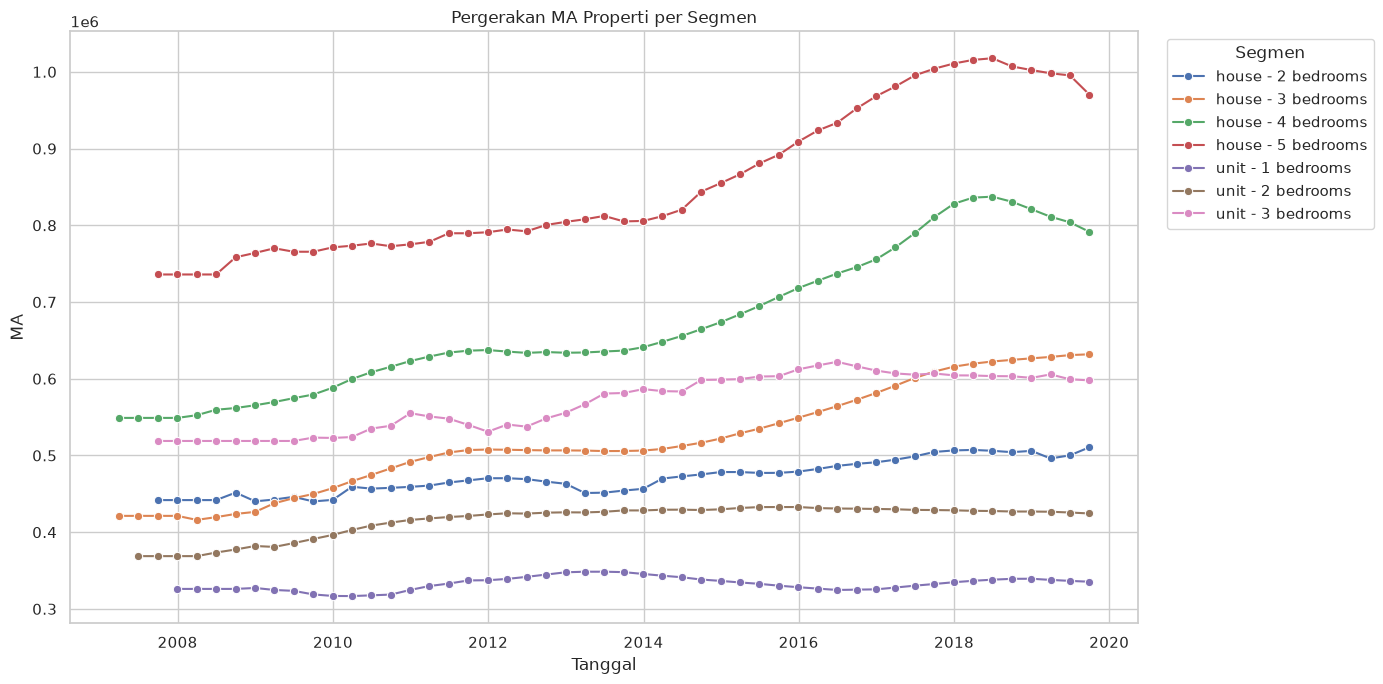

In [5]:
plot_df = df.copy()
plot_df["segment"] = plot_df["type"].astype(str) + " - " + plot_df["bedrooms"].astype(str) + " bedrooms"

plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df, x="saledate", y="MA", hue="segment", marker="o")
plt.title("Pergerakan MA Properti per Segmen")
plt.xlabel("Tanggal")
plt.ylabel("MA")
plt.legend(title="Segmen", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Feature Engineering Time Series

Lag dan rolling feature dibuat per grup `type + bedrooms`. Semua fitur historis memakai `shift(1)`, sehingga nilai target pada periode yang sama atau masa depan tidak masuk ke fitur.

In [6]:
def add_time_series_features(data: pd.DataFrame) -> pd.DataFrame:
    featured = data.copy()
    group_cols = ["type", "bedrooms"]

    featured["year"] = featured["saledate"].dt.year
    featured["quarter"] = featured["saledate"].dt.quarter
    featured["type_code"] = featured["type"].cat.codes
    featured["bedrooms_num"] = featured["bedrooms"].astype(int)

    grouped_ma = featured.groupby(group_cols, observed=True)["MA"]
    featured["ma_lag_1"] = grouped_ma.shift(1)
    featured["ma_lag_2"] = grouped_ma.shift(2)
    featured["ma_lag_4"] = grouped_ma.shift(4)
    featured["ma_roll_mean_4"] = grouped_ma.transform(lambda series: series.shift(1).rolling(4).mean())
    featured["ma_roll_std_4"] = grouped_ma.transform(lambda series: series.shift(1).rolling(4).std(ddof=0))

    return featured

model_df = add_time_series_features(df)
feature_cols = [
    "year",
    "quarter",
    "type_code",
    "bedrooms_num",
    "ma_lag_1",
    "ma_lag_2",
    "ma_lag_4",
    "ma_roll_mean_4",
    "ma_roll_std_4",
]

display(model_df.head(10))
print(model_df[feature_cols].isna().sum())

,saledate,MA,type,bedrooms,year,quarter,type_code,bedrooms_num,ma_lag_1,ma_lag_2,ma_lag_4,ma_roll_mean_4,ma_roll_std_4
0,2007-09-30,441854,house,2,2007,3,0,2,NaN,NaN,NaN,NaN,NaN
1,2007-12-31,441854,house,2,2007,4,0,2,"441,854.00",NaN,NaN,NaN,NaN
2,2008-03-31,441854,house,2,2008,1,0,2,"441,854.00","441,854.00",NaN,NaN,NaN
3,2008-06-30,441854,house,2,2008,2,0,2,"441,854.00","441,854.00",NaN,NaN,NaN
4,2008-09-30,451583,house,2,2008,3,0,2,"441,854.00","441,854.00","441,854.00","441,854.00",0.00
5,2008-12-31,440256,house,2,2008,4,0,2,"451,583.00","441,854.00","441,854.00","444,286.25","4,212.78"
6,2009-03-31,442566,house,2,2009,1,0,2,"440,256.00","451,583.00","441,854.00","443,886.75","4,491.07"
7,2009-06-30,446113,house,2,2009,2,0,2,"442,566.00","440,256.00","441,854.00","444,064.75","4,420.53"
8,2009-09-30,440123,house,2,2009,3,0,2,"446,113.00","442,566.00","451,583.00","445,129.50","4,270.17"
9,2009-12-31,442131,house,2,2009,4,0,2,"440,123.00","446,113.00","440,256.00","442,264.50","2,424.97"


year               0
quarter            0
type_code          0
bedrooms_num       0
ma_lag_1           7
ma_lag_2          14
ma_lag_4          28
ma_roll_mean_4    28
ma_roll_std_4     28
dtype: int64


In [7]:
model_ready = model_df.dropna(subset=feature_cols + ["MA"]).copy()

assert model_ready[feature_cols + ["MA"]].isna().sum().sum() == 0
assert (model_ready["ma_lag_1"] != model_ready["MA"]).any(), "Cek kembali fitur lag; lag tidak boleh sama persis dengan target seluruh baris"

print(f"Baris sebelum lag/rolling: {len(model_df)}")
print(f"Baris siap model: {len(model_ready)}")
display(model_ready.head())

Baris sebelum lag/rolling: 347
Baris siap model: 319


,saledate,MA,type,bedrooms,year,quarter,type_code,bedrooms_num,ma_lag_1,ma_lag_2,ma_lag_4,ma_roll_mean_4,ma_roll_std_4
4,2008-09-30,451583,house,2,2008,3,0,2,"441,854.00","441,854.00","441,854.00","441,854.00",0.00
5,2008-12-31,440256,house,2,2008,4,0,2,"451,583.00","441,854.00","441,854.00","444,286.25","4,212.78"
6,2009-03-31,442566,house,2,2009,1,0,2,"440,256.00","451,583.00","441,854.00","443,886.75","4,491.07"
7,2009-06-30,446113,house,2,2009,2,0,2,"442,566.00","440,256.00","441,854.00","444,064.75","4,420.53"
8,2009-09-30,440123,house,2,2009,3,0,2,"446,113.00","442,566.00","451,583.00","445,129.50","4,270.17"


## Split Kronologis Train-Test

Data sebelum 2017 digunakan sebagai training set. Data 2017 sampai 2019 menjadi test set, agar evaluasi menyerupai kondisi forecast ke periode berikutnya.

In [8]:
split_date = pd.Timestamp("2017-01-01")
train_df = model_ready[model_ready["saledate"] < split_date].copy()
test_df = model_ready[model_ready["saledate"] >= split_date].copy()

X_train = train_df[feature_cols]
y_train = train_df["MA"]
X_test = test_df[feature_cols]
y_test = test_df["MA"]

print(f"Train: {train_df['saledate'].min().date()} - {train_df['saledate'].max().date()} | {len(train_df)} baris")
print(f"Test : {test_df['saledate'].min().date()} - {test_df['saledate'].max().date()} | {len(test_df)} baris")

Train: 2008-03-31 - 2016-12-31 | 242 baris
Test : 2017-03-31 - 2019-09-30 | 77 baris


## Fungsi Evaluasi

Evaluasi memakai MAE, RMSE, MAPE, sMAPE, WMAPE, dan R2. Untuk model log-target, prediksi dikembalikan ke skala asli sebelum metrik dihitung.

In [9]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator)) * 100


def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def evaluate_predictions(model_name, y_true, y_pred):
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0.01)
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((np.asarray(y_true) - y_pred) / np.asarray(y_true))) * 100,
        "sMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

## Baseline dan Random Forest

Baseline sederhana memakai nilai kuartal yang sama tahun sebelumnya (`ma_lag_4`). Model utama yang dibandingkan adalah Random Forest pada target asli dan Random Forest pada transformasi `log1p(MA)`.

In [10]:
baseline_pred = test_df["ma_lag_4"].to_numpy()

rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_log_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_log_model.fit(X_train, np.log1p(y_train))
rf_log_pred = np.expm1(rf_log_model.predict(X_test))

metrics_df = pd.DataFrame([
    evaluate_predictions("Baseline Lag-4", y_test, baseline_pred),
    evaluate_predictions("Random Forest", y_test, rf_pred),
    evaluate_predictions("Random Forest Log Target", y_test, rf_log_pred),
]).sort_values("WMAPE").reset_index(drop=True)

display(metrics_df)

,Model,MAE,RMSE,MAPE,sMAPE,WMAPE,R2
0,Baseline Lag-4,"17,069.88","25,225.36",2.42,2.46,2.78,0.99
1,Random Forest,"17,404.03","30,459.00",2.13,2.16,2.83,0.98
2,Random Forest Log Target,"17,545.91","30,180.35",2.15,2.19,2.86,0.98


In [11]:
required_metrics = {"MAE", "RMSE", "MAPE", "sMAPE", "WMAPE", "R2"}
assert required_metrics.issubset(metrics_df.columns)
assert np.isfinite(metrics_df[list(required_metrics)].to_numpy()).all()

print("Metrik evaluasi lengkap dan valid.")

Metrik evaluasi lengkap dan valid.


## Visualisasi Hasil Test Set

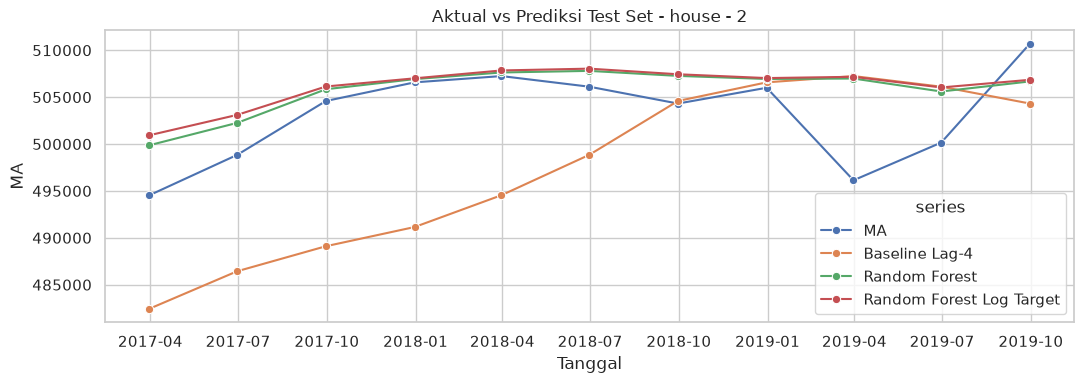

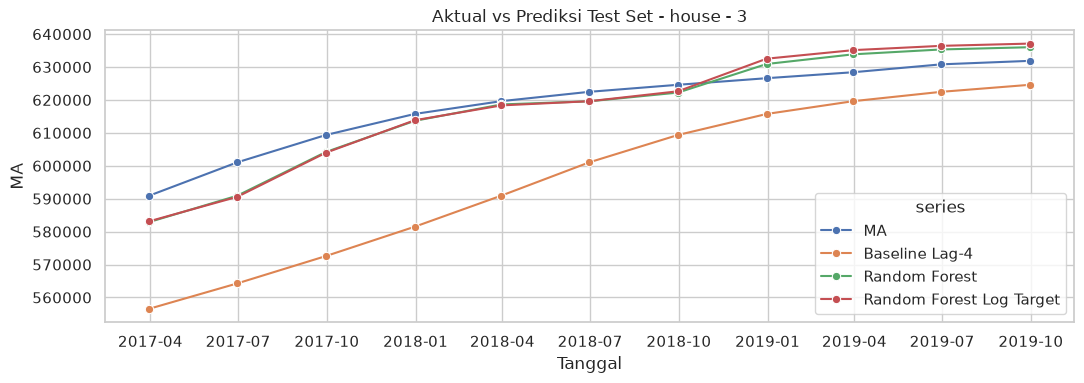

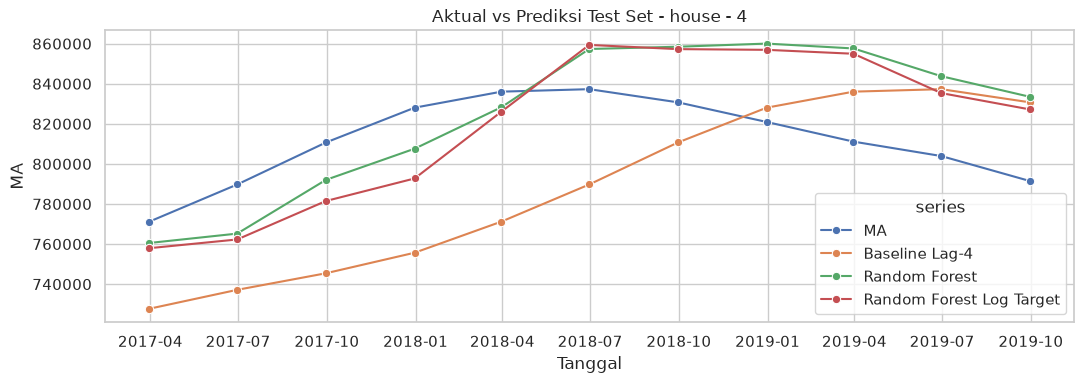

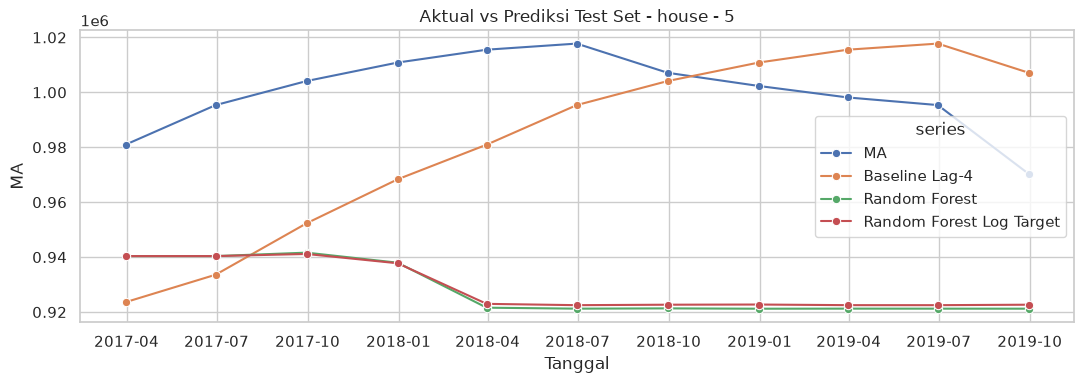

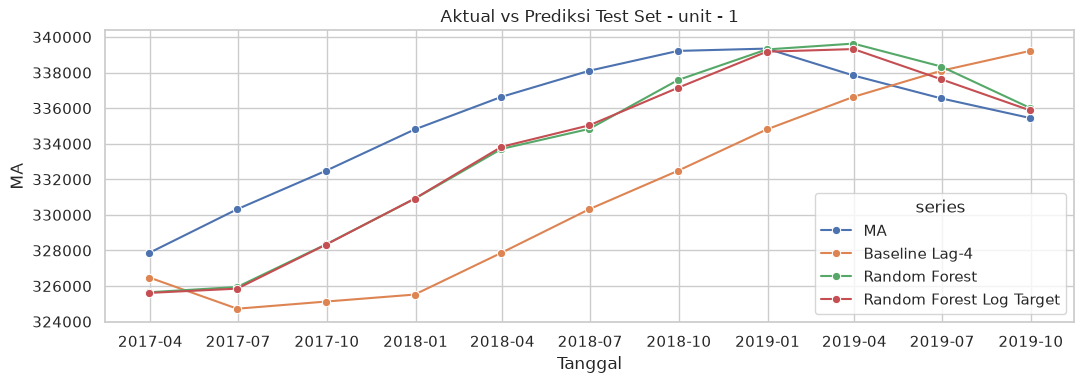

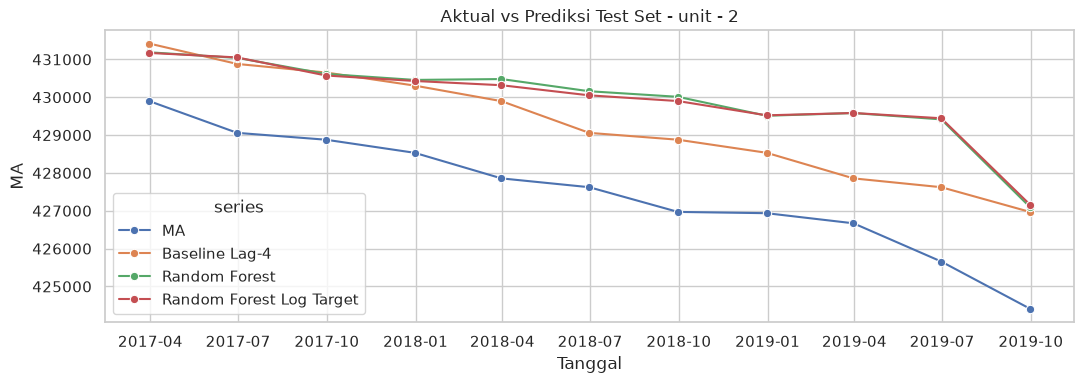

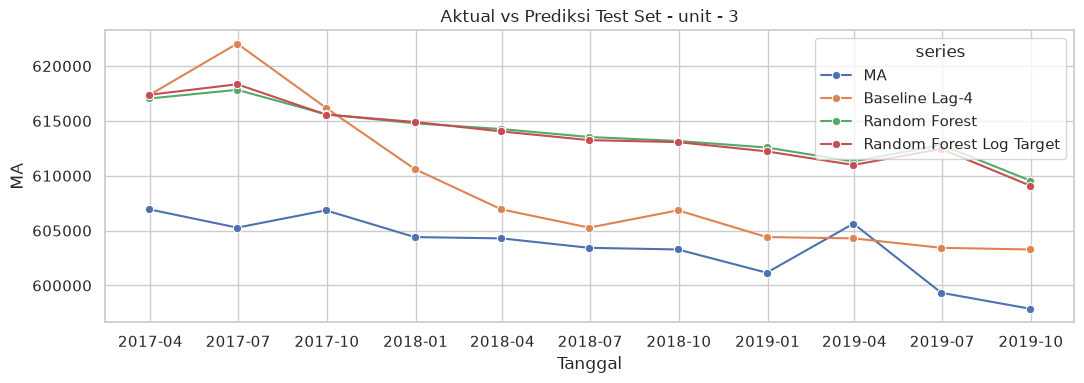

In [12]:
pred_plot = test_df[["saledate", "type", "bedrooms", "MA"]].copy()
pred_plot["Baseline Lag-4"] = baseline_pred
pred_plot["Random Forest"] = rf_pred
pred_plot["Random Forest Log Target"] = rf_log_pred
pred_plot["segment"] = pred_plot["type"].astype(str) + " - " + pred_plot["bedrooms"].astype(str)

long_pred = pred_plot.melt(
    id_vars=["saledate", "type", "bedrooms", "segment"],
    value_vars=["MA", "Baseline Lag-4", "Random Forest", "Random Forest Log Target"],
    var_name="series",
    value_name="value",
)

for segment, segment_df in long_pred.groupby("segment"):
    plt.figure(figsize=(11, 4))
    sns.lineplot(data=segment_df, x="saledate", y="value", hue="series", marker="o")
    plt.title(f"Aktual vs Prediksi Test Set - {segment}")
    plt.xlabel("Tanggal")
    plt.ylabel("MA")
    plt.tight_layout()
    plt.show()

## Model Final dan Forecast Recursive 4 Kuartal

Model terbaik dipilih dari dua variasi Random Forest berdasarkan WMAPE test set. Model kemudian dilatih ulang pada seluruh data yang sudah memiliki fitur historis, lalu digunakan untuk forecast empat kuartal setelah `2019-09-30`.

In [13]:
rf_metrics = metrics_df[metrics_df["Model"].isin(["Random Forest", "Random Forest Log Target"])]
best_model_name = rf_metrics.sort_values("WMAPE").iloc[0]["Model"]

if best_model_name == "Random Forest Log Target":
    final_model = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    final_model.fit(model_ready[feature_cols], np.log1p(model_ready["MA"]))
    uses_log_target = True
else:
    final_model = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    final_model.fit(model_ready[feature_cols], model_ready["MA"])
    uses_log_target = False

print(f"Model final: {best_model_name}")

Model final: Random Forest


In [14]:
type_categories = list(df["type"].cat.categories)
type_code_map = {category: code for code, category in enumerate(type_categories)}


def build_future_features(history_values, future_date, property_type, bedrooms):
    recent_4 = history_values[-4:]
    return {
        "year": future_date.year,
        "quarter": future_date.quarter,
        "type_code": type_code_map[property_type],
        "bedrooms_num": int(bedrooms),
        "ma_lag_1": history_values[-1],
        "ma_lag_2": history_values[-2],
        "ma_lag_4": history_values[-4],
        "ma_roll_mean_4": float(np.mean(recent_4)),
        "ma_roll_std_4": float(np.std(recent_4, ddof=0)),
    }


def predict_ma(feature_row):
    feature_frame = pd.DataFrame([feature_row], columns=feature_cols)
    raw_pred = final_model.predict(feature_frame)[0]
    if uses_log_target:
        raw_pred = np.expm1(raw_pred)
    return float(max(raw_pred, 0.01))

last_date = df["saledate"].max()
future_dates = pd.date_range(
    start=last_date + pd.offsets.QuarterEnd(1),
    periods=4,
    freq="QE",
)

forecast_rows = []
for (property_type, bedrooms), group_df in df.groupby(["type", "bedrooms"], observed=True):
    history = group_df.sort_values("saledate")["MA"].astype(float).tolist()

    for future_date in future_dates:
        future_features = build_future_features(history, future_date, property_type, bedrooms)
        forecast_value = predict_ma(future_features)
        history.append(forecast_value)
        forecast_rows.append({
            "saledate": future_date,
            "type": property_type,
            "bedrooms": int(bedrooms),
            "Forecasted MA": forecast_value,
        })

forecast_df = pd.DataFrame(forecast_rows).sort_values(["type", "bedrooms", "saledate"]).reset_index(drop=True)
display(forecast_df)

,saledate,type,bedrooms,Forecasted MA
0,2019-12-31,house,2,"511,934.92"
1,2020-03-31,house,2,"514,170.62"
2,2020-06-30,house,2,"518,103.60"
3,2020-09-30,house,2,"520,194.60"
4,2019-12-31,house,3,"633,650.03"
5,2020-03-31,house,3,"633,892.84"
6,2020-06-30,house,3,"633,920.76"
7,2020-09-30,house,3,"634,342.58"
8,2019-12-31,house,4,"802,864.63"
9,2020-03-31,house,4,"802,849.28"


In [15]:
expected_forecast_rows = df[["type", "bedrooms"]].drop_duplicates().shape[0] * 4

assert forecast_df.shape[0] == expected_forecast_rows == 28
assert forecast_df["Forecasted MA"].gt(0).all()
assert forecast_df["saledate"].min() == pd.Timestamp("2019-12-31")
assert forecast_df["saledate"].max() == pd.Timestamp("2020-09-30")

print("Forecast valid: 7 kombinasi kategori x 4 kuartal = 28 baris, semua prediksi positif.")

Forecast valid: 7 kombinasi kategori x 4 kuartal = 28 baris, semua prediksi positif.


## Visualisasi Forecast

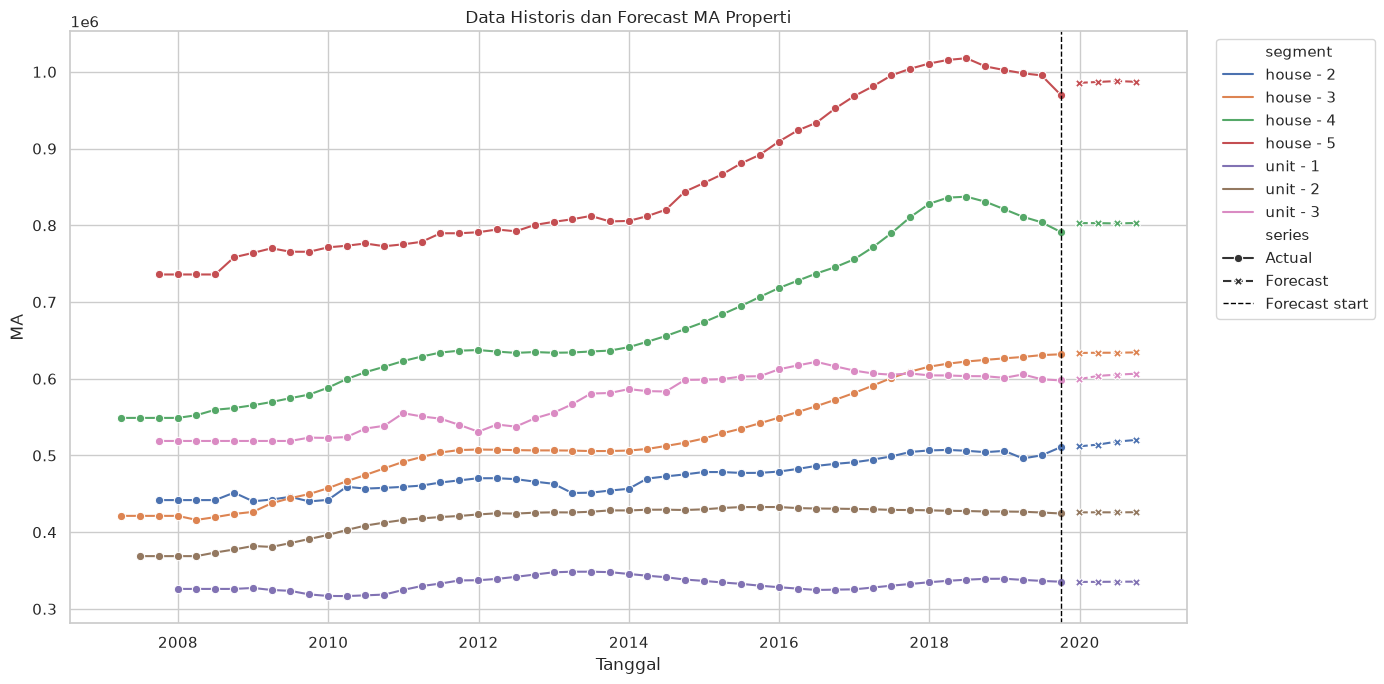

In [16]:
history_plot = df[["saledate", "type", "bedrooms", "MA"]].copy()
history_plot = history_plot.rename(columns={"MA": "value"})
history_plot["series"] = "Actual"

future_plot = forecast_df.rename(columns={"Forecasted MA": "value"}).copy()
future_plot["series"] = "Forecast"

combined_plot = pd.concat([
    history_plot[["saledate", "type", "bedrooms", "value", "series"]],
    future_plot[["saledate", "type", "bedrooms", "value", "series"]],
], ignore_index=True)
combined_plot["segment"] = combined_plot["type"].astype(str) + " - " + combined_plot["bedrooms"].astype(str)

plt.figure(figsize=(14, 7))
sns.lineplot(data=combined_plot, x="saledate", y="value", hue="segment", style="series", markers=True)
plt.axvline(df["saledate"].max(), color="black", linestyle="--", linewidth=1, label="Forecast start")
plt.title("Data Historis dan Forecast MA Properti")
plt.xlabel("Tanggal")
plt.ylabel("MA")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Ringkasan

Notebook ini membangun model forecasting kuartalan untuk `MA` properti dengan fitur kalender, kategori, lag, dan rolling per segmen `type + bedrooms`. Evaluasi membandingkan baseline lag musiman dengan dua variasi Random Forest, lalu model Random Forest terbaik dipakai untuk menghasilkan forecast empat kuartal ke depan.